# distopt: structural metrics experiments (alignment, χ_eff, commutator, MUDAG K)

This notebook implements a **minimal-engineering experiment suite** for the repo’s current harness:
- static undirected graphs + symmetric doubly-stochastic mixing `W`
- strongly convex quadratic locals
- algorithms: DGD / EXTRA / Gradient Tracking / MUDAG

Focus:
1) **Topology–heterogeneity alignment** via permuting the same locals across nodes.
2) **χ_eff** (Laplacian pseudoinverse quadratic form) as a predictor of time-to-accuracy.
3) The **MUDAG K gap** by sweeping `c_K`.
4) A **commutator (ε_C)** sweep using shared-eigenbasis vs random-eigenbasis endpoints.

Notes:
- `distopt` uses the **average** objective $f(x)=(1/n)∑_i f_i(x)$. For χ_eff we use unscaled local gradients $g_i=∇f_i(x^*)=A_i x^*-b_i$ (a global $1/n$ factor only rescales χ_eff).

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Ensure repo root is on sys.path so `import research...` works no matter
# which working directory VS Code/Jupyter chooses for this notebook.
_here = Path().resolve()
_repo_root = None
for p in [_here, *_here.parents]:
    if (p / "pyproject.toml").exists():
        _repo_root = p
        break
if _repo_root is not None and str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from research.code.distopt.generators import (
    path_adjacency,
    cycle_adjacency,
    complete_adjacency,
    erdos_renyi_adjacency,
    make_graph_from_adjacency,
    make_wishart_ridge_problem,
    make_shared_eigenbasis_problem,
    make_random_spd_problem,
)
from research.code.distopt.algorithms import DGD, EXTRA, GradientTracking, MUDAG
from research.code.distopt.problems import DistributedQuadraticProblem
from research.code.distopt.runner import run_experiment, MaxMixRounds

In [2]:
# --------- helpers copied (lightly) from default_experiments.ipynb ---------

def _consensus_init(X: np.ndarray) -> np.ndarray:
    """Return consensus initialization with the same average as X."""
    x0_bar = np.mean(X, axis=0)
    return np.repeat(x0_bar[None, :], X.shape[0], axis=0)


def make_connected_er_graph(n: int, p: float, *, seed: int, lazy: float, max_tries: int = 50):
    for k in range(max_tries):
        adj = erdos_renyi_adjacency(n, p, seed=seed + k)
        graph = make_graph_from_adjacency(adj, lazy=lazy)
        if bool(graph.ensure_stats().connected):
            return graph
    raise RuntimeError('Failed to sample a connected ER graph; increase max_tries or p')


def alpha_from_factor(problem: DistributedQuadraticProblem, factor: float) -> float:
    L_l = float(problem.ensure_stats().L_l)
    return float(factor) / L_l


def extract_xy(res, *, x_key: str, y_key: str, max_x: float | None = None):
    xs = np.array([row[x_key] for row in res.history], dtype=float)
    ys = np.array([row[y_key] for row in res.history], dtype=float)
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    keep = np.concatenate([[True], xs[1:] > xs[:-1]])
    xs, ys = xs[keep], ys[keep]
    if max_x is not None:
        mask = xs <= float(max_x)
        if np.any(mask):
            xs, ys = xs[mask], ys[mask]
    return xs, ys


def interp_to_grid(xs: np.ndarray, ys: np.ndarray, grid: np.ndarray, *, y_floor: float = 1e-16) -> np.ndarray:
    ys = np.maximum(ys, y_floor)
    if xs.size == 0:
        return np.full_like(grid, fill_value=np.nan, dtype=float)
    if xs[0] > grid[0]:
        xs = np.concatenate([[grid[0]], xs])
        ys = np.concatenate([[ys[0]], ys])
    if xs[-1] < grid[-1]:
        xs = np.concatenate([xs, [grid[-1]]])
        ys = np.concatenate([ys, [ys[-1]]])
    return np.interp(grid, xs, ys)


def aggregate_seed_curves(res_by_seed: dict[int, object], *, x_key: str, y_key: str, grid: np.ndarray, max_x: float | None = None):
    per_seed = {}
    ys_stack = []
    for seed, res in res_by_seed.items():
        xs, ys = extract_xy(res, x_key=x_key, y_key=y_key, max_x=max_x)
        y_grid = interp_to_grid(xs, ys, grid)
        per_seed[int(seed)] = y_grid
        ys_stack.append(y_grid)
    ys_stack = np.stack(ys_stack, axis=0)
    return np.median(ys_stack, axis=0), per_seed


def first_budget_to_tol(res, *, x_key: str, y_key: str, tol: float) -> float | None:
    for row in res.history:
        if float(row[y_key]) <= float(tol):
            return float(row[x_key])
    return None


def _fmt_budget(x: float | None) -> str:
    if x is None:
        return '-'
    if not np.isfinite(x):
        return '∞'
    if x >= 1000:
        return f'{x:.0f}'
    return f'{x:.1f}'


def print_graph_stats(graph) -> None:
    g = graph.ensure_stats()
    print(f'connected={g.connected}  gamma={g.gamma:.4g}  chi={g.chi:.3g}  lambda2_W={g.lambda2_W:.6f}')
    print(f'min_eig(W)={float(np.min(g.eigvals_W)):.6g}  max_eig(W)={float(np.max(g.eigvals_W)):.6g}')


def print_problem_stats(problem) -> None:
    s = problem.ensure_stats()
    print(f'kappa_g={s.kappa_g:.3g}  L_g={s.L_g:.3g}  mu_g={s.mu_g:.3g}  L_l={s.L_l:.3g}  beta={s.beta:.3g}')

In [3]:
# --------- structural metrics: χ_eff + ordering + commutator ---------

def grad_heterogeneity_at_x_star(problem: DistributedQuadraticProblem) -> np.ndarray:
    x = problem.x_star
    return np.einsum('ijk,k->ij', problem.A, x) - problem.b


def chi_eff_from_G(graph, G: np.ndarray, *, tol: float | None = None):
    """Return χ_eff = sum_{λ_k>0} ||v_k^T G||^2 / λ_k for L = I-W.

    G is (n,d). This sums the per-dimension pseudoinverse quadratic form.
    """
    if tol is None:
        tol = float(getattr(graph, 'tol', 1e-12))
    L = graph.L
    eigvals, V = np.linalg.eigh(L)
    proj = V.T @ G  # (n,d)
    energy = np.sum(proj**2, axis=1)  # per mode
    inv = np.zeros_like(eigvals)
    inv[eigvals > tol] = 1.0 / eigvals[eigvals > tol]
    contrib = inv * energy
    return float(np.sum(contrib)), {'eigvals': eigvals, 'energy': energy, 'contrib': contrib}


def fiedler_order(graph, *, tol: float | None = None) -> np.ndarray:
    if tol is None:
        tol = float(getattr(graph, 'tol', 1e-12))
    eigvals, V = np.linalg.eigh(graph.L)
    pos = np.flatnonzero(eigvals > tol)
    if pos.size == 0:
        return np.arange(graph.n)
    idx = int(pos[0])  # smallest positive eigenvalue
    v = V[:, idx]
    return np.argsort(v)


def pc1_task_score(G: np.ndarray) -> np.ndarray:
    Gc = G - np.mean(G, axis=0, keepdims=True)
    _u, _s, vt = np.linalg.svd(Gc, full_matrices=False)
    pc1 = vt[0]
    return Gc @ pc1


def commutator_metric(A: np.ndarray, *, max_pairs: int | None = None, rng: np.random.Generator | None = None) -> float:
    """ε_C = max_{i<j} ||A_i A_j - A_j A_i||_F / (||A_i||_F ||A_j||_F)."""
    A = np.asarray(A, dtype=np.float64)
    n = int(A.shape[0])
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    if max_pairs is not None and len(pairs) > int(max_pairs):
        if rng is None:
            rng = np.random.default_rng(0)
        idx = rng.choice(len(pairs), size=int(max_pairs), replace=False)
        pairs = [pairs[int(k)] for k in idx]
    norms = np.linalg.norm(A.reshape(n, -1), axis=1)
    eps = 0.0
    for i, j in pairs:
        denom = float(norms[i] * norms[j])
        if denom == 0.0:
            continue
        C = A[i] @ A[j] - A[j] @ A[i]
        val = float(np.linalg.norm(C, ord='fro') / denom)
        eps = max(eps, val)
    return float(eps)

In [4]:
# --------- permutations / assignments (setup #1) ---------

def permute_problem(problem: DistributedQuadraticProblem, perm: np.ndarray) -> DistributedQuadraticProblem:
    perm = np.asarray(perm, dtype=int)
    if perm.shape != (problem.n,):
        raise ValueError('perm must have shape (n,)')
    return DistributedQuadraticProblem(
        graph=problem.graph,
        A=problem.A[perm],
        b=problem.b[perm],
        validate=True,
        tol=problem.tol,
        metadata={**problem.metadata, 'perm_kind': 'custom'},
    )


def make_assignment_perm(graph, scores: np.ndarray, kind: str, *, rng: np.random.Generator, bins: int = 4) -> np.ndarray:
    n = int(graph.n)
    if kind == 'random':
        return rng.permutation(n)

    nodes = fiedler_order(graph)
    tasks_sorted = np.argsort(scores)

    if kind == 'adversarial':
        perm = np.empty(n, dtype=int)
        perm[nodes] = tasks_sorted
        return perm

    if kind == 'clustered':
        chunks = np.array_split(tasks_sorted, int(bins))
        chunks = [rng.permutation(ch) for ch in chunks]
        tasks = np.concatenate(chunks, axis=0)
        perm = np.empty(n, dtype=int)
        perm[nodes] = tasks
        return perm

    raise ValueError(f'Unknown kind={kind!r}')

In [5]:
# --------- global defaults ---------

seeds = [0, 1, 2]
n = 20
d = 20

# Lazification makes W PSD, which MUDAG requires.
lazy = 0.5

max_mix = 5000
log_every = 10
tol_dist = 1e-3

alpha_factors = [0.02, 0.05, 0.1, 0.2]
c_K_grid = [0.5, 1.0, 2.0, 3.0]

mix_grid = np.linspace(0.0, float(max_mix), 251)

problem_kwargs = dict(m_per_node=50, lambda_reg=1.0, noise_std=0.0)

GRAPH_KINDS = ['path', 'cycle', 'er', 'complete']
ASSIGN_KINDS = ['random', 'clustered', 'adversarial']

print('seeds:', seeds)
print('n,d:', (n, d), 'lazy:', lazy)
print('max_mix:', max_mix, 'log_every:', log_every, 'tol_dist:', tol_dist)

seeds: [0, 1, 2]
n,d: (20, 20) lazy: 0.5
max_mix: 5000 log_every: 10 tol_dist: 0.001


In [6]:
def make_graph(kind: str, *, seed: int) -> object:
    if kind == 'path':
        return make_graph_from_adjacency(path_adjacency(n), lazy=lazy)
    if kind == 'cycle':
        return make_graph_from_adjacency(cycle_adjacency(n), lazy=lazy)
    if kind == 'complete':
        return make_graph_from_adjacency(complete_adjacency(n), lazy=lazy)
    if kind == 'er':
        # p chosen so it’s typically connected at n=20.
        return make_connected_er_graph(n, p=0.25, seed=seed, lazy=lazy)
    raise ValueError(f'Unknown graph kind={kind!r}')


def make_base_problem(graph, *, seed: int) -> DistributedQuadraticProblem:
    return make_wishart_ridge_problem(graph, d=d, seed=seed, **problem_kwargs)


def summarize_runs(res_by_seed: dict[int, object], *, tol: float) -> dict[str, float]:
    mix_to = []
    grad_to = []
    final_dist = []
    final_cons = []
    for seed, res in res_by_seed.items():
        m = first_budget_to_tol(res, x_key='mix_rounds', y_key='dist_to_x_star', tol=tol)
        g = first_budget_to_tol(res, x_key='grad_evals_per_node', y_key='dist_to_x_star', tol=tol)
        mix_to.append(np.inf if m is None else m)
        grad_to.append(np.inf if g is None else g)
        final_dist.append(float(res.history[-1]['dist_to_x_star']))
        final_cons.append(float(res.history[-1]['consensus_error']))
    return {
        'med_mix_to_tol': float(np.median(mix_to)),
        'med_grads_to_tol': float(np.median(grad_to)),
        'med_final_dist': float(np.median(final_dist)),
        'med_final_cons': float(np.median(final_cons)),
    }


def pick_best_hp(summary_rows: list[dict[str, object]]):
    finite = [r for r in summary_rows if np.isfinite(float(r['med_mix_to_tol']))]
    if finite:
        return finite[0]['hp']
    return min(summary_rows, key=lambda r: float(r['med_final_dist']))['hp']

In [7]:
# --------- hyperparameter calibration on RANDOM assignment only ---------

def calibrate_hyperparams_for_graph(kind: str) -> dict[str, object]:
    # Build per-seed base problems (same graph kind, same family).
    base = {}  # seed -> (graph, problem, X0)
    for seed in seeds:
        graph = make_graph(kind, seed=seed)
        problem = make_base_problem(graph, seed=seed)
        rng = np.random.default_rng(seed)
        X0 = _consensus_init(rng.normal(size=(problem.n, problem.d)))
        base[int(seed)] = (graph, problem, X0)

    # Tune DGD / EXTRA / GT by alpha factor, and MUDAG by c_K.
    rows_by_alg = {}

    def _run_sweep(alg_name: str, hp_grid: list[float]) -> list[dict[str, object]]:
        out = []
        for hp in hp_grid:
            res_by_seed = {}
            for seed, (_g, pr, X0) in base.items():
                if alg_name == 'DGD':
                    alpha = alpha_from_factor(pr, hp)
                    alg = DGD(alpha=alpha)
                elif alg_name == 'EXTRA':
                    alpha = alpha_from_factor(pr, hp)
                    alg = EXTRA(alpha=alpha)
                elif alg_name == 'GT':
                    alpha = alpha_from_factor(pr, hp)
                    alg = GradientTracking(alpha=alpha)
                elif alg_name == 'MUDAG':
                    alg = MUDAG(c_K=float(hp))
                else:
                    raise ValueError(alg_name)
                alg.check(pr)
                res_by_seed[int(seed)] = run_experiment(
                    pr,
                    alg,
                    stop=[MaxMixRounds(max_mix)],
                    X0=X0,
                    log_every=log_every,
                )
            summ = summarize_runs(res_by_seed, tol=tol_dist)
            out.append({'hp': hp, **summ})
        out.sort(key=lambda r: (float(r['med_mix_to_tol']), float(r['med_grads_to_tol']), float(r['med_final_dist'])))
        return out

    rows_by_alg['DGD'] = _run_sweep('DGD', alpha_factors)
    rows_by_alg['EXTRA'] = _run_sweep('EXTRA', alpha_factors)
    rows_by_alg['GT'] = _run_sweep('GT', alpha_factors)
    rows_by_alg['MUDAG'] = _run_sweep('MUDAG', c_K_grid)

    best = {alg: pick_best_hp(rows) for alg, rows in rows_by_alg.items()}
    return {'best': best, 'sweeps': rows_by_alg}

In [8]:
# --------- Experiment A: alignment via permutation (setup #1) ---------

def run_alignment_experiment(kind: str, *, calib: dict[str, object]):
    best = calib['best']

    # For reporting: same graph kind, but note ER graph may differ by seed.
    results = []
    curves = {assign: {alg: {} for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']} for assign in ASSIGN_KINDS}

    for seed in seeds:
        graph = make_graph(kind, seed=seed)
        base_problem = make_base_problem(graph, seed=seed)
        rng = np.random.default_rng(seed)
        X0 = _consensus_init(rng.normal(size=(base_problem.n, base_problem.d)))

        # Task scoring based on gradients at x* of the base problem.
        G = grad_heterogeneity_at_x_star(base_problem)
        scores = pc1_task_score(G)

        # For each assignment kind: build permuted problem and compute χ_eff.
        for assign in ASSIGN_KINDS:
            perm = make_assignment_perm(graph, scores, assign, rng=rng)
            pr = permute_problem(base_problem, perm)
            chi_eff, _diag = chi_eff_from_G(graph, grad_heterogeneity_at_x_star(pr))

            # Run algorithms with frozen hyperparams.
            # DGD / EXTRA / GT use alpha factors; MUDAG uses c_K.
            alpha_dgd = alpha_from_factor(pr, float(best['DGD']))
            alpha_extra = alpha_from_factor(pr, float(best['EXTRA']))
            alpha_gt = alpha_from_factor(pr, float(best['GT']))
            c_K = float(best['MUDAG'])

            algs = {
                'DGD': DGD(alpha=alpha_dgd),
                'EXTRA': EXTRA(alpha=alpha_extra),
                'GT': GradientTracking(alpha=alpha_gt),
                'MUDAG': MUDAG(c_K=c_K),
            }

            for alg_name, alg in algs.items():
                alg.check(pr)
                res = run_experiment(pr, alg, stop=[MaxMixRounds(max_mix)], X0=X0, log_every=log_every)
                curves[assign][alg_name][int(seed)] = res

            # Only append one row per (seed,assign); time-to-accuracy summarized across algs later.
            results.append({'seed': int(seed), 'assign': assign, 'chi_eff': float(chi_eff)})

    return results, curves


def summarize_alignment_tables(results: list[dict[str, object]], curves: dict, *, tol: float):
    # Summarize median time-to-accuracy over seeds, per assignment and algorithm.
    out = []
    for assign in ASSIGN_KINDS:
        row = {'assign': assign}
        chis = [float(r['chi_eff']) for r in results if r['assign'] == assign]
        row['med_chi_eff'] = float(np.median(chis)) if chis else float('nan')
        for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
            summ = summarize_runs(curves[assign][alg], tol=tol)
            row[f'{alg}_mix'] = summ['med_mix_to_tol']
            row[f'{alg}_grads'] = summ['med_grads_to_tol']
        out.append(row)
    return out


def plot_alignment_curves(kind: str, curves: dict, *, x_key: str, y_key: str, grid: np.ndarray, max_x: float):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for ax, assign in zip(axes, ASSIGN_KINDS):
        for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
            med, per_seed = aggregate_seed_curves(curves[assign][alg], x_key=x_key, y_key=y_key, grid=grid, max_x=max_x)
            ax.plot(grid, med, label=alg)
        ax.set_title(f'{assign}')
        ax.set_xlabel(x_key)
        ax.grid(True, which='both', ls=':')
    axes[0].set_ylabel(y_key)
    axes[0].legend()
    fig.suptitle(f'Experiment A ({kind}): {y_key} vs {x_key} (median over seeds)')
    plt.show()


Graph kind: path
Best hyperparams: {'DGD': 0.02, 'EXTRA': 0.2, 'GT': 0.02, 'MUDAG': 1.0}
{'assign': 'random', 'med_chi_eff': 562.2084645982529, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 140.0, 'EXTRA_grads': 140.0, 'GT_mix': 4640.0, 'GT_grads': 2321.0, 'MUDAG_mix': 2380.0, 'MUDAG_grads': 170.0}
{'assign': 'clustered', 'med_chi_eff': 1199.517088067275, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 160.0, 'EXTRA_grads': 160.0, 'GT_mix': inf, 'GT_grads': inf, 'MUDAG_mix': 2380.0, 'MUDAG_grads': 170.0}
{'assign': 'adversarial', 'med_chi_eff': 1223.5707943863672, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 160.0, 'EXTRA_grads': 160.0, 'GT_mix': inf, 'GT_grads': inf, 'MUDAG_mix': 2380.0, 'MUDAG_grads': 170.0}


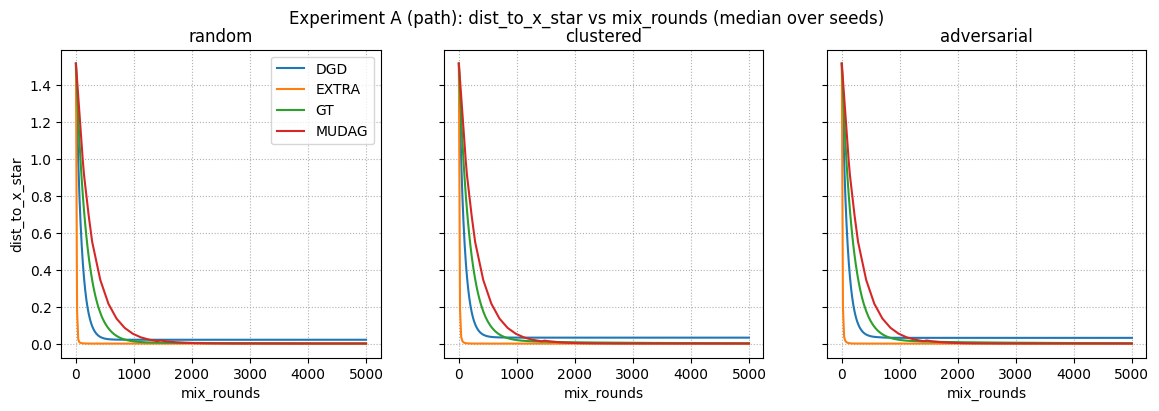

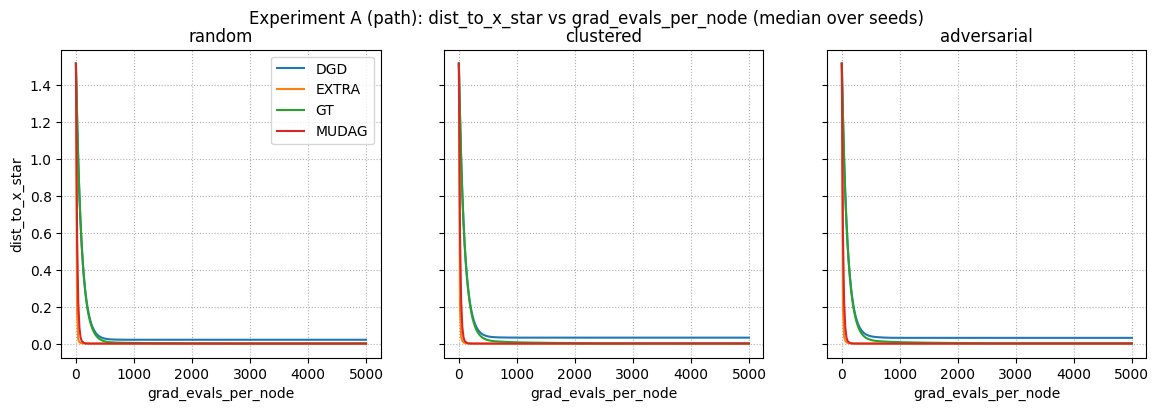


Graph kind: cycle
Best hyperparams: {'DGD': 0.02, 'EXTRA': 0.2, 'GT': 0.05, 'MUDAG': 1.0}
{'assign': 'random', 'med_chi_eff': 295.1305745788369, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 70.0, 'EXTRA_grads': 70.0, 'GT_mix': 1080.0, 'GT_grads': 541.0, 'MUDAG_mix': 1280.0, 'MUDAG_grads': 160.0}
{'assign': 'clustered', 'med_chi_eff': 410.5519763800903, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 80.0, 'EXTRA_grads': 80.0, 'GT_mix': 1180.0, 'GT_grads': 591.0, 'MUDAG_mix': 1280.0, 'MUDAG_grads': 160.0}
{'assign': 'adversarial', 'med_chi_eff': 417.5454980309429, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 80.0, 'EXTRA_grads': 80.0, 'GT_mix': 1160.0, 'GT_grads': 581.0, 'MUDAG_mix': 1280.0, 'MUDAG_grads': 160.0}


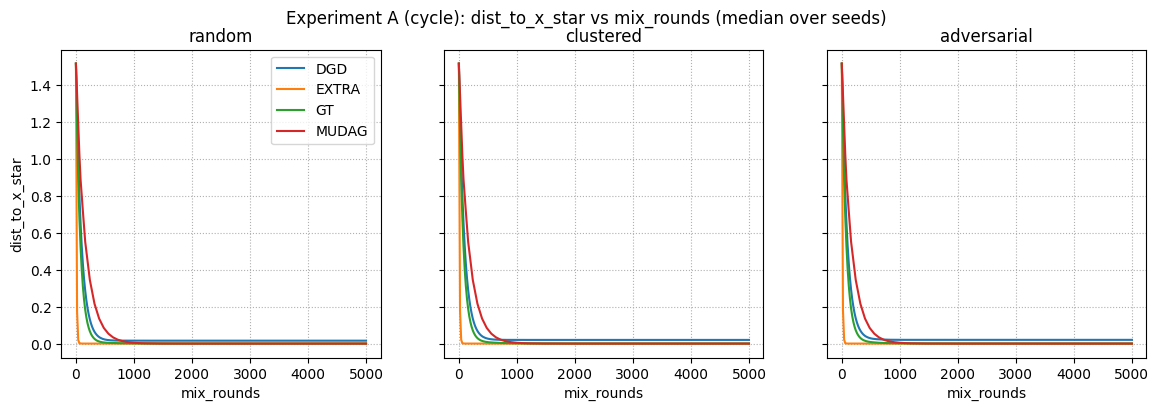

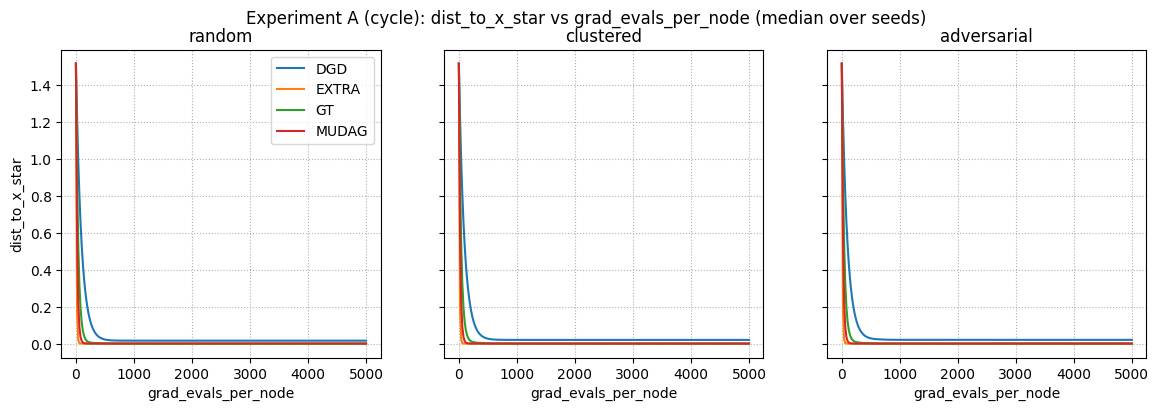


Graph kind: er
Best hyperparams: {'DGD': 0.02, 'EXTRA': 0.2, 'GT': 0.2, 'MUDAG': 0.5}
{'assign': 'random', 'med_chi_eff': 53.28630707307886, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 70.0, 'EXTRA_grads': 70.0, 'GT_mix': 140.0, 'GT_grads': 71.0, 'MUDAG_mix': 320.0, 'MUDAG_grads': 160.0}
{'assign': 'clustered', 'med_chi_eff': 53.28630707307886, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 70.0, 'EXTRA_grads': 70.0, 'GT_mix': 140.0, 'GT_grads': 71.0, 'MUDAG_mix': 320.0, 'MUDAG_grads': 160.0}
{'assign': 'adversarial', 'med_chi_eff': 53.28630707307886, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 70.0, 'EXTRA_grads': 70.0, 'GT_mix': 140.0, 'GT_grads': 71.0, 'MUDAG_mix': 320.0, 'MUDAG_grads': 160.0}


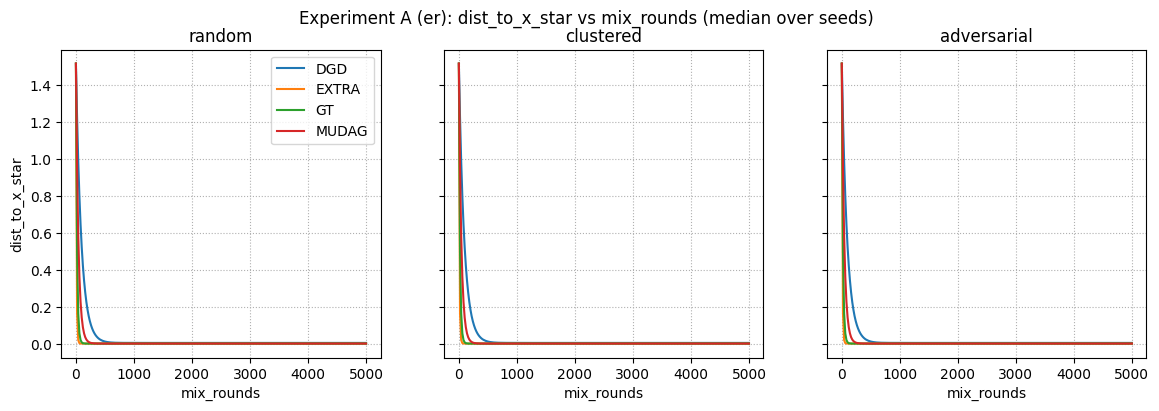

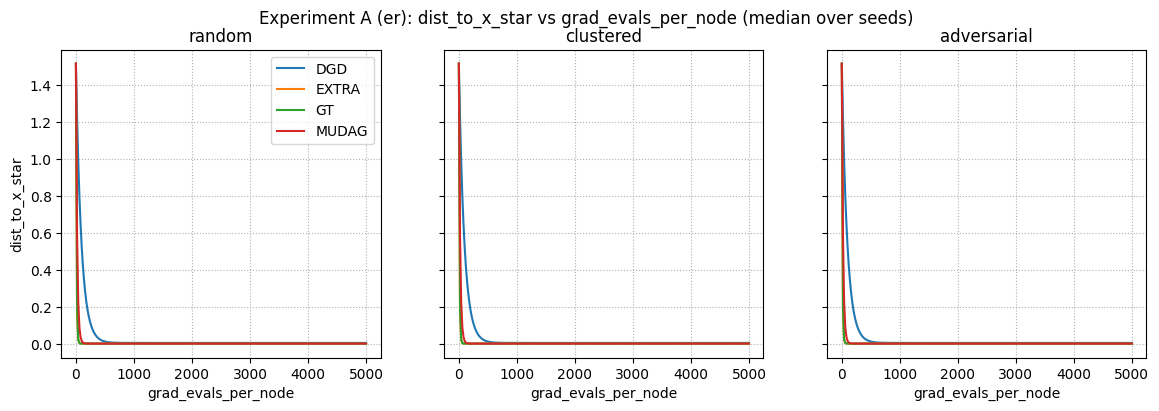


Graph kind: complete
Best hyperparams: {'DGD': 0.02, 'EXTRA': 0.2, 'GT': 0.2, 'MUDAG': 0.5}
{'assign': 'random', 'med_chi_eff': 53.28630707307886, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 70.0, 'EXTRA_grads': 70.0, 'GT_mix': 140.0, 'GT_grads': 71.0, 'MUDAG_mix': 320.0, 'MUDAG_grads': 160.0}
{'assign': 'clustered', 'med_chi_eff': 53.28630707307886, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 70.0, 'EXTRA_grads': 70.0, 'GT_mix': 140.0, 'GT_grads': 71.0, 'MUDAG_mix': 320.0, 'MUDAG_grads': 160.0}
{'assign': 'adversarial', 'med_chi_eff': 53.28630707307886, 'DGD_mix': inf, 'DGD_grads': inf, 'EXTRA_mix': 70.0, 'EXTRA_grads': 70.0, 'GT_mix': 140.0, 'GT_grads': 71.0, 'MUDAG_mix': 320.0, 'MUDAG_grads': 160.0}


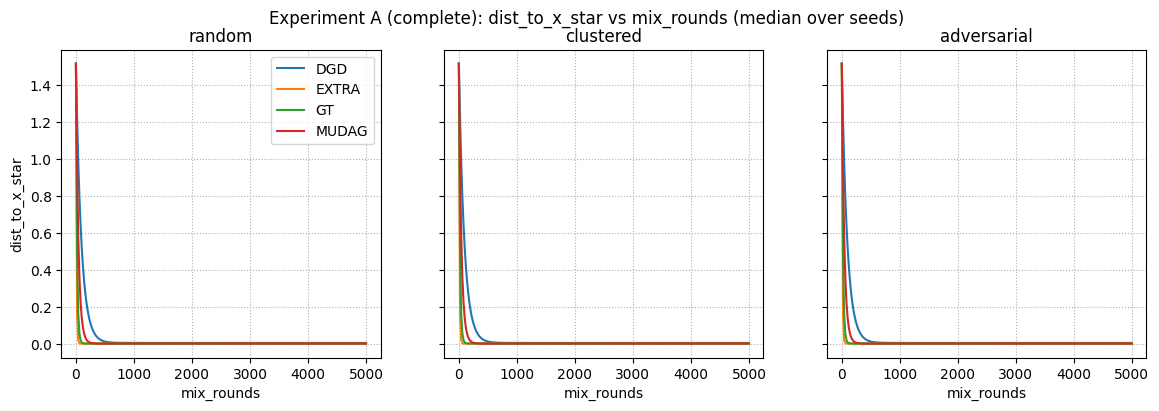

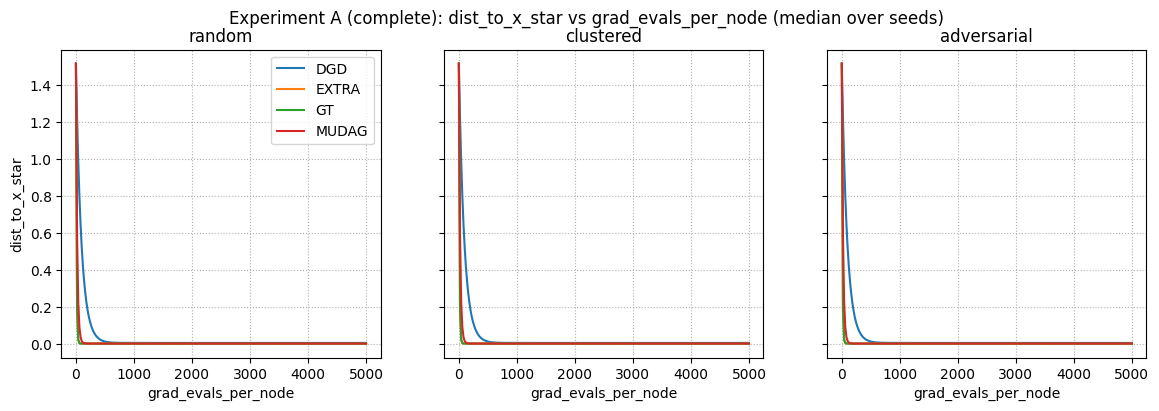

In [9]:
# Run Experiment A for all graph kinds (prints best hyperparams + summary tables)

all_calib = {}
all_tables = {}
all_curves = {}

for kind in GRAPH_KINDS:
    print("\n" + "=" * 80)
    print("Graph kind:", kind)
    calib = calibrate_hyperparams_for_graph(kind)
    all_calib[kind] = calib
    print("Best hyperparams:", calib["best"])

    results, curves = run_alignment_experiment(kind, calib=calib)
    all_curves[kind] = curves

    table = summarize_alignment_tables(results, curves, tol=tol_dist)
    all_tables[kind] = table
    for row in table:
        print(row)

    # Plots: dist_to_x_star vs mix rounds (comm) and vs grad evals (comp)
    plot_alignment_curves(
        kind,
        curves,
        x_key="mix_rounds",
        y_key="dist_to_x_star",
        grid=mix_grid,
        max_x=float(max_mix),
    )
    # For grad axis, choose a grid based on observed max grad budget.
    grad_max = 0.0
    for assign in ASSIGN_KINDS:
        for alg in ["DGD", "EXTRA", "GT", "MUDAG"]:
            for _seed, res in curves[assign][alg].items():
                grad_max = max(grad_max, float(res.history[-1]["grad_evals_per_node"]))
    grad_grid = np.linspace(0.0, grad_max, 251)
    plot_alignment_curves(
        kind,
        curves,
        x_key="grad_evals_per_node",
        y_key="dist_to_x_star",
        grid=grad_grid,
        max_x=float(grad_max),
    )

Graph stats:
connected=True  gamma=0.01631  chi=40.9  lambda2_W=0.983686
min_eig(W)=0.333333  max_eig(W)=1
No finite points for DGD
No finite points for DGD


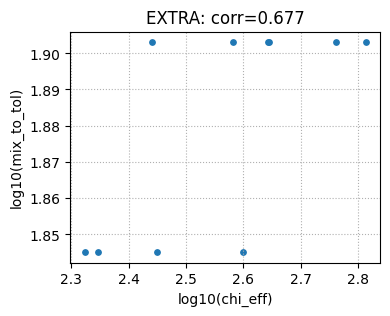

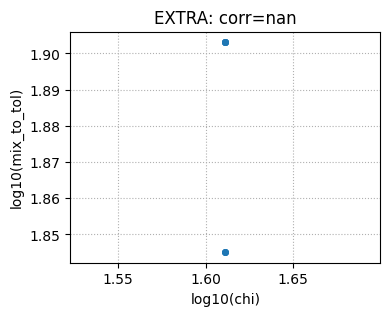

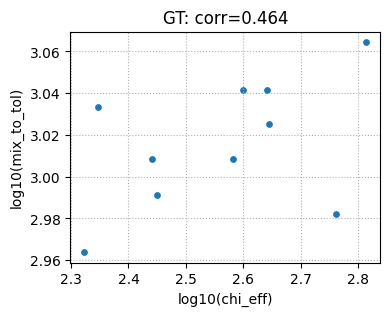

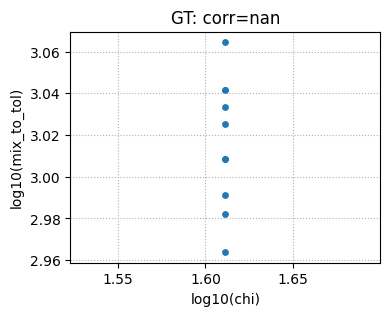

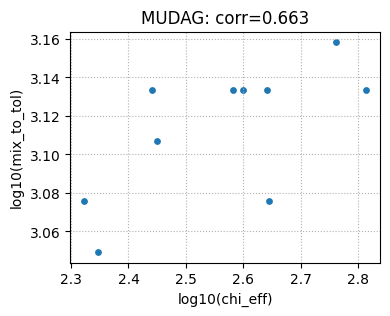

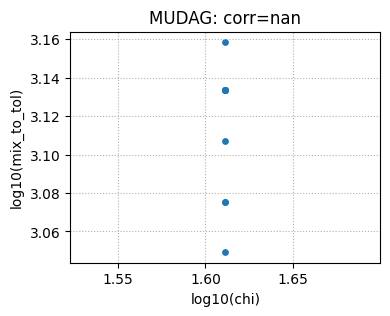

In [13]:
# --------- Experiment B: χ_eff predictiveness (setup #2) ---------
# Kept small by default; scale N_instances once the workflow looks good.

def run_predictiveness(kind: str, *, N_instances: int = 10, seed0: int = 10):
    calib = all_calib[kind]['best']

    # Fix one graph (per kind) for the predictiveness sweep.
    graph = make_graph(kind, seed=seed0)
    print('Graph stats:')
    print_graph_stats(graph)

    rows = []
    for s in range(seed0, seed0 + int(N_instances)):
        pr = make_wishart_ridge_problem(graph, d=d, seed=s, **problem_kwargs)
        stats = pr.ensure_stats()
        G = grad_heterogeneity_at_x_star(pr)
        chi_eff, _ = chi_eff_from_G(graph, G)

        rng = np.random.default_rng(s)
        X0 = _consensus_init(rng.normal(size=(pr.n, pr.d)))

        algs = {
            'DGD': DGD(alpha=alpha_from_factor(pr, float(calib['DGD']))),
            'EXTRA': EXTRA(alpha=alpha_from_factor(pr, float(calib['EXTRA']))),
            'GT': GradientTracking(alpha=alpha_from_factor(pr, float(calib['GT']))),
            'MUDAG': MUDAG(c_K=float(calib['MUDAG'])),
        }
        for alg_name, alg in algs.items():
            alg.check(pr)
            res = run_experiment(pr, alg, stop=[MaxMixRounds(max_mix)], X0=X0, log_every=log_every)
            m = first_budget_to_tol(res, x_key='mix_rounds', y_key='dist_to_x_star', tol=tol_dist)
            g = first_budget_to_tol(res, x_key='grad_evals_per_node', y_key='dist_to_x_star', tol=tol_dist)
            rows.append({
                'kind': kind,
                'instance_seed': int(s),
                'alg': alg_name,
                'mix_to_tol': float(np.inf if m is None else m),
                'grads_to_tol': float(np.inf if g is None else g),
                'chi_eff': float(chi_eff),
                'chi': float(graph.ensure_stats().chi),
                'gamma': float(graph.ensure_stats().gamma),
                'kappa_g': float(stats.kappa_g),
                'beta': float(stats.beta),
            })
    return rows


def plot_predictiveness(rows: list[dict[str, object]], *, alg: str, x_key: str, y_key: str):
    xs = np.array([r[x_key] for r in rows if r['alg'] == alg], dtype=float)
    ys = np.array([r[y_key] for r in rows if r['alg'] == alg], dtype=float)
    mask = np.isfinite(xs) & np.isfinite(ys) & (xs > 0) & (ys > 0)
    xs, ys = xs[mask], ys[mask]
    if xs.size == 0:
        print('No finite points for', alg)
        return
    lx, ly = np.log10(xs), np.log10(ys)
    if xs.size < 2 or float(np.std(lx)) == 0.0 or float(np.std(ly)) == 0.0:
        corr = float('nan')
    else:
        corr = float(np.corrcoef(lx, ly)[0, 1])
    plt.figure(figsize=(4, 3))
    plt.scatter(lx, ly, s=15)
    plt.xlabel(f'log10({x_key})')
    plt.ylabel(f'log10({y_key})')
    plt.title(f'{alg}: corr={corr:.3f}')
    plt.grid(True, ls=':')
    plt.show()


rows_pred = run_predictiveness('cycle', N_instances=10, seed0=10)
for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
    plot_predictiveness(rows_pred, alg=alg, x_key='chi_eff', y_key='mix_to_tol')
    plot_predictiveness(rows_pred, alg=alg, x_key='chi', y_key='mix_to_tol')

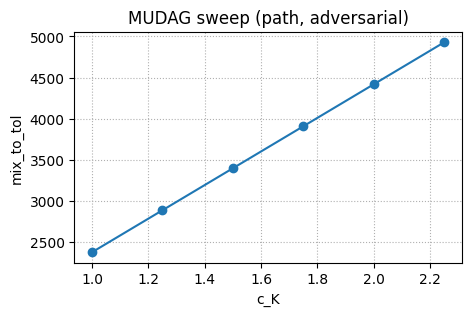

In [11]:
# --------- Experiment C: MUDAG K gap (setup #3) ---------

def mudag_K_sweep(kind: str, assign: str, *, seed: int = 0, cK_grid: np.ndarray | None = None):
    if cK_grid is None:
        cK_grid = np.linspace(0.25, 4.0, 16)
    graph = make_graph(kind, seed=seed)
    base_problem = make_base_problem(graph, seed=seed)
    rng = np.random.default_rng(seed)
    X0 = _consensus_init(rng.normal(size=(base_problem.n, base_problem.d)))

    G = grad_heterogeneity_at_x_star(base_problem)
    scores = pc1_task_score(G)
    perm = make_assignment_perm(graph, scores, assign, rng=rng)
    pr = permute_problem(base_problem, perm)

    rows = []
    for cK in cK_grid:
        alg = MUDAG(c_K=float(cK))
        alg.check(pr)
        res = run_experiment(pr, alg, stop=[MaxMixRounds(max_mix)], X0=X0, log_every=log_every)
        m = first_budget_to_tol(res, x_key='mix_rounds', y_key='dist_to_x_star', tol=tol_dist)
        g = first_budget_to_tol(res, x_key='grad_evals_per_node', y_key='dist_to_x_star', tol=tol_dist)
        rows.append({
            'c_K': float(cK),
            'mudag_K': float(res.history[0].get('mudag_K', np.nan)),
            'mix_to_tol': float(np.inf if m is None else m),
            'grads_to_tol': float(np.inf if g is None else g),
        })
    return rows


rowsK = mudag_K_sweep('path', 'adversarial', seed=0)
plt.figure(figsize=(5, 3))
plt.plot([r['c_K'] for r in rowsK], [r['mix_to_tol'] for r in rowsK], marker='o')
plt.xlabel('c_K')
plt.ylabel('mix_to_tol')
plt.title('MUDAG sweep (path, adversarial)')
plt.grid(True, ls=':')
plt.show()

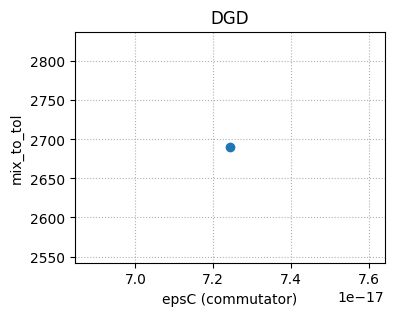

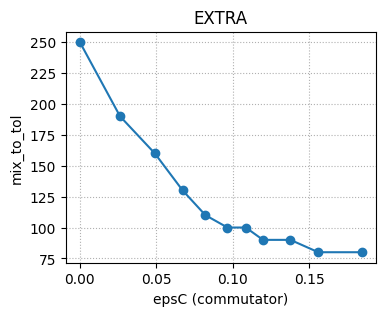

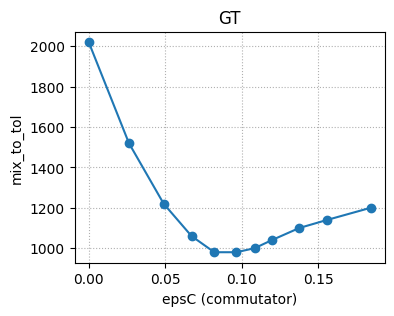

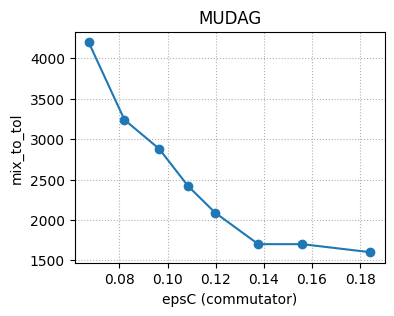

In [12]:
# --------- Experiment D: commutator sweep (setup #4) ---------

def commutator_sweep(*, n0: int = 20, d0: int = 10, seed: int = 0, rho_grid: np.ndarray | None = None):
    if rho_grid is None:
        rho_grid = np.linspace(0.0, 1.0, 11)

    adj = cycle_adjacency(n0)
    graph = make_graph_from_adjacency(adj, lazy=0.5)

    pr_shared = make_shared_eigenbasis_problem(graph, d=d0, mu=1.0, L=10.0, seed=seed)
    pr_rand = make_random_spd_problem(graph, d=d0, mu=1.0, L=10.0, seed=seed + 1)

    # Force shared b across endpoints to isolate the Hessian/eigenbasis axis.
    pr_rand = DistributedQuadraticProblem(graph=graph, A=pr_rand.A, b=pr_shared.b, validate=True)

    rng = np.random.default_rng(seed)
    X0 = _consensus_init(rng.normal(size=(n0, d0)))

    # Reuse calibrated cycle hyperparams if available, else fallback.
    if 'cycle' in all_calib:
        hp = all_calib['cycle']['best']
        alpha_dgd = float(hp['DGD'])
        alpha_extra = float(hp['EXTRA'])
        alpha_gt = float(hp['GT'])
        cK = float(hp['MUDAG'])
    else:
        alpha_dgd = 0.1
        alpha_extra = 0.1
        alpha_gt = 0.1
        cK = 1.0

    rows = []
    for rho in rho_grid:
        A = (1.0 - float(rho)) * pr_shared.A + float(rho) * pr_rand.A
        pr = DistributedQuadraticProblem(graph=graph, A=A, b=pr_shared.b, validate=True)
        epsC = commutator_metric(pr.A)
        chi_eff, _ = chi_eff_from_G(graph, grad_heterogeneity_at_x_star(pr))

        algs = {
            'DGD': DGD(alpha=alpha_from_factor(pr, alpha_dgd)),
            'EXTRA': EXTRA(alpha=alpha_from_factor(pr, alpha_extra)),
            'GT': GradientTracking(alpha=alpha_from_factor(pr, alpha_gt)),
            'MUDAG': MUDAG(c_K=cK),
        }
        for alg_name, alg in algs.items():
            alg.check(pr)
            res = run_experiment(pr, alg, stop=[MaxMixRounds(max_mix)], X0=X0, log_every=log_every)
            m = first_budget_to_tol(res, x_key='mix_rounds', y_key='dist_to_x_star', tol=tol_dist)
            rows.append({
                'rho': float(rho),
                'epsC': float(epsC),
                'chi_eff': float(chi_eff),
                'alg': alg_name,
                'mix_to_tol': float(np.inf if m is None else m),
            })
    return rows


rowsC = commutator_sweep(n0=20, d0=10, seed=0)
for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
    xs = np.array([r['epsC'] for r in rowsC if r['alg'] == alg], dtype=float)
    ys = np.array([r['mix_to_tol'] for r in rowsC if r['alg'] == alg], dtype=float)
    plt.figure(figsize=(4, 3))
    plt.plot(xs, ys, marker='o')
    plt.xlabel('epsC (commutator)')
    plt.ylabel('mix_to_tol')
    plt.title(alg)
    plt.grid(True, ls=':')
    plt.show()